In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [3]:
# %% 2. Load dataset (train / validation / test)
emotion_dataset = load_dataset('dair-ai/emotion')

train_text,  train_label = emotion_dataset['train']['text'],      emotion_dataset['train']['label']
val_text,    val_label   = emotion_dataset['validation']['text'], emotion_dataset['validation']['label']
test_text,   test_label  = emotion_dataset['test']['text'],       emotion_dataset['test']['label']

label_names = emotion_dataset['train'].features['label'].names
print(label_names)

df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
print(df_train.isnull().sum())

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
text     0
label    0
dtype: int64


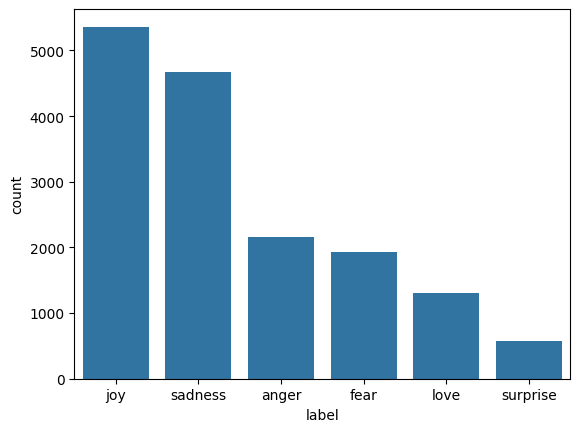

In [4]:
# %% 3. EDA
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.show()

In [5]:

# %% 4. Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(train_text)          # fit ONLY on train data


def to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    # FIX: padding='pre' so RNN/LSTM/GRU read the real words last, not zeros
    return pad_sequences(seq, maxlen=max_len, padding='pre', truncating='post')


padded_train = to_padded(train_text)
padded_val   = to_padded(val_text)
padded_test  = to_padded(test_text)

train_labels = np.array(train_label)
val_labels   = np.array(val_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))   # 6 -> one output neuron per emotion
print("Vocabulary Size:", len(tokenizer.word_index))
print("Sequence shape:", padded_train.shape)

Vocabulary Size: 15213
Sequence shape: (16000, 50)


In [6]:

# %% 5. Class weights + early stopping
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

class_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(train_labels), y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))


def make_early_stopping():
    # new object per model so patience counter starts fresh
    return EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)



In [7]:

# %% 6. Helper to build / train / evaluate
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, SimpleRNN, LSTM, GRU,
                                     Bidirectional, Dense, Dropout)


def build_model(layer, embed_dim=128, bidirectional=False):
    wrap = Bidirectional if bidirectional else (lambda x: x)
    model = Sequential([
        Input(shape=(max_len,)),                              # replaces deprecated input_length
        Embedding(input_dim=max_words, output_dim=embed_dim),
        wrap(layer(128, return_sequences=True)),
        Dropout(0.5),
        wrap(layer(64)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),             # 6 probabilities, sum = 1
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def train_and_eval(model, name):
    model.fit(
        padded_train, train_labels,
        validation_data=(padded_val, val_labels),   # FIX: validation set, not test set
        epochs=20, batch_size=32,
        class_weight=class_weight_dict,
        callbacks=[make_early_stopping()],
    )
    loss, acc = model.evaluate(padded_test, test_labels)  # test used only once, at the end
    print(f"{name} Loss: {loss:.4f}  Accuracy: {acc:.4f}")
    return loss, acc


# %% 6.1 Simple RNN
rnn_model = build_model(SimpleRNN)
rnn_loss, rnn_accuracy = train_and_eval(rnn_model, "RNN")

# %% 6.2 LSTM
lstm_model = build_model(LSTM)
lstm_loss, lstm_accuracy = train_and_eval(lstm_model, "LSTM")

# %% 6.3 GRU
gru_model = build_model(GRU)
gru_loss, gru_accuracy = train_and_eval(gru_model, "GRU")

# %% 6.4 Compare
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy],
}).sort_values(by='Test Accuracy', ascending=False)
print(result_df)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.1715 - loss: 1.9281 - val_accuracy: 0.2725 - val_loss: 1.7342
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2994 - loss: 1.5714 - val_accuracy: 0.3965 - val_loss: 1.4519
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6204 - loss: 0.9423 - val_accuracy: 0.4650 - val_loss: 1.3751
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5693 - loss: 1.0657 - val_accuracy: 0.5760 - val_loss: 1.1408
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8189 - loss: 0.4890 - val_accuracy: 0.7910 - val_loss: 0.7261
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8543 - loss: 0.3960 - val_accuracy: 0.5905 - val_loss: 1.2948
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8620 - loss: 0.3856 - val_accuracy: 0.7900 - val_loss: 0.8017
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9251 - loss: 0.2129 - val_acc

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,662 (13.18 MB)

 Trainable params: 3,454,662 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5881 - loss: 1.0413 - val_accuracy: 0.9115 - val_loss: 0.2761
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9310 - loss: 0.1937 - val_accuracy: 0.9280 - val_loss: 0.2069
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9510 - loss: 0.1327 - val_accuracy: 0.9325 - val_loss: 0.1978
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9638 - loss: 0.0986 - val_accuracy: 0.9295 - val_loss: 0.2358
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9691 - loss: 0.0921 - val_accuracy: 0.9315 - val_loss: 0.2275
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9762 - loss: 0.0682 - val_accuracy: 0.9385 - val_loss: 0.2182
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9245 - loss: 0.2065
BiGRU Loss: 0.2065  Accuracy: 0.9245
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


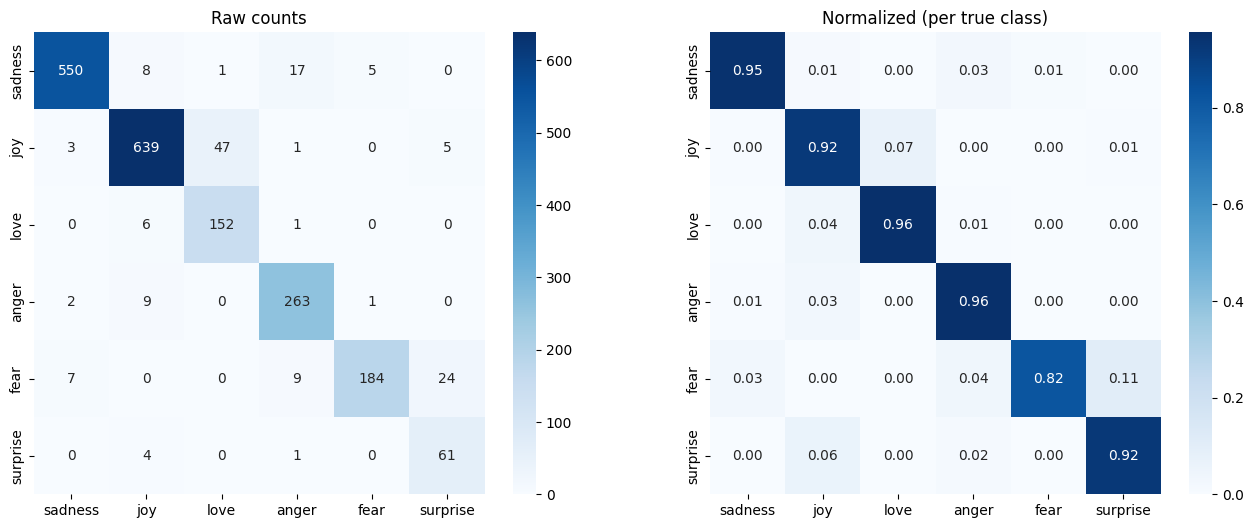

              precision    recall  f1-score   support

     sadness       0.98      0.95      0.96       581
         joy       0.96      0.92      0.94       695
        love       0.76      0.96      0.85       159
       anger       0.90      0.96      0.93       275
        fear       0.97      0.82      0.89       224
    surprise       0.68      0.92      0.78        66

    accuracy                           0.92      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.93      0.92      0.93      2000



In [8]:

# %% 7. Advanced Bidirectional GRU (300D embeddings)
BiGRU = build_model(GRU, embed_dim=300, bidirectional=True)
BiGRU.summary()
BiGRU_loss, BiGRU_accuracy = train_and_eval(BiGRU, "BiGRU")

# %% 8. Confusion matrices (raw + normalized)
from sklearn.metrics import confusion_matrix, classification_report

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Raw counts')
sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions, normalize='true'), annot=True,
            fmt='.2f', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('Normalized (per true class)')
plt.show()

print(classification_report(test_labels, BiGRU_predictions, target_names=label_names))

In [9]:

# %% 9. Final predictions
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!",
]
sample_preds = np.argmax(BiGRU.predict(to_padded(sample_texts)), axis=1)

for text, p in zip(sample_texts, sample_preds):
    print(f"Text: {text}\nPredicted Emotion: {label_names[p]}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy

Text: I feel so alone and hopeless today.
Predicted Emotion: sadness

Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger

Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear

Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise



In [10]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print("Saved to", model_dir)

Saved to Artifacts
